<a href="https://colab.research.google.com/github/TanveerAhmed01/CRUD-Profile/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc,
    classification_report
)

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Churn_Data.csv to Churn_Data.csv


In [ ]:
df = pd.read_csv('Churn_Data.csv')

In [ ]:
df.shape

(10000, 14)

In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

In [ ]:
print("Missing values:\n", df.isnull().sum())


Missing values:
 CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [ ]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)


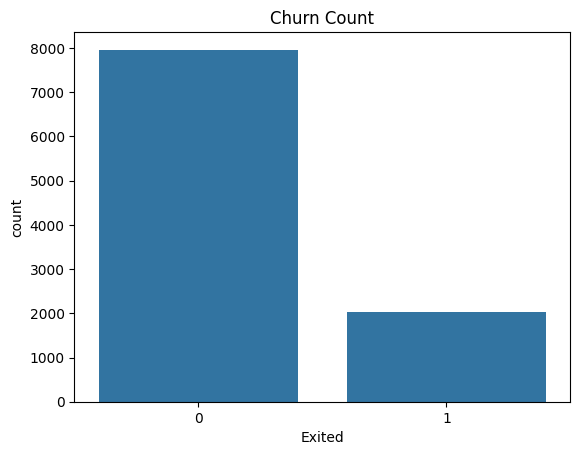

In [ ]:
sns.countplot(x='Exited', data=df)
plt.title('Churn Count')
plt.show()

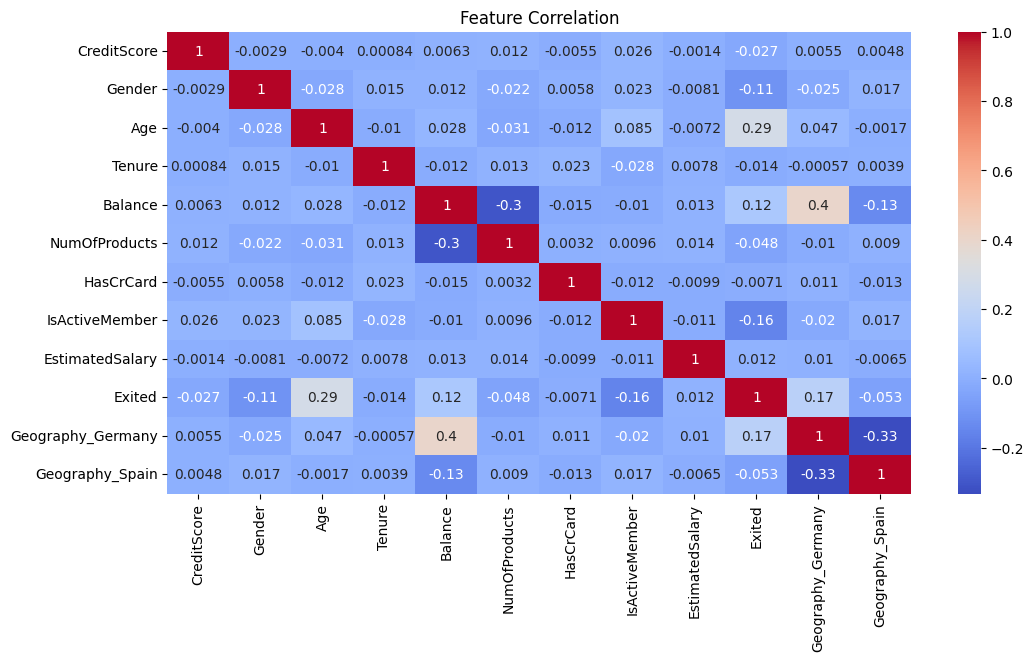

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

In [ ]:
X = df.drop('Exited', axis=1)
y = df['Exited']

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Shapes -> Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Shapes -> Train: (7000, 11) Val: (1500, 11) Test: (1500, 11)


In [ ]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)



= KNN_k1 =
Validation Accuracy: 0.7820
Test Accuracy:       0.7707
Precision:           0.4348
Recall:              0.4262
F1-score:            0.4305


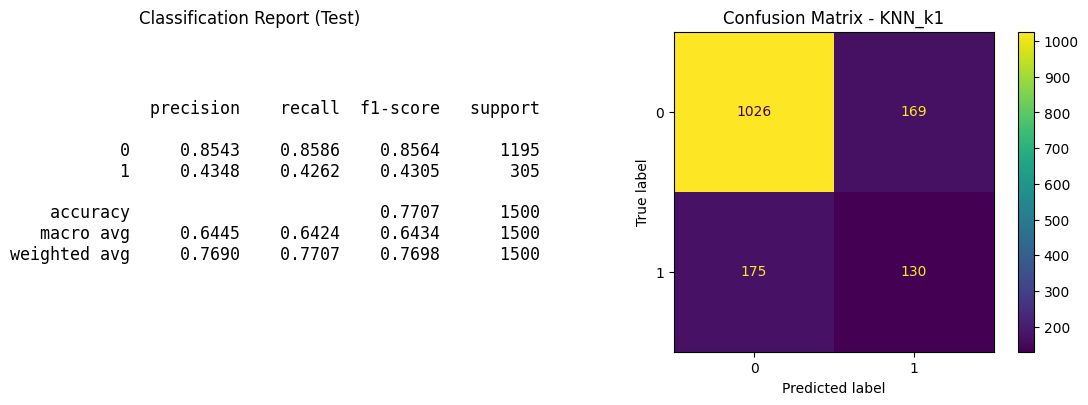

In [ ]:
model = KNeighborsClassifier(n_neighbors=1)

def evaluate_model(name, model, X_tr, y_tr, X_v, y_v, X_te, y_te):
    # Train
    model.fit(X_tr, y_tr)

    val_pred = model.predict(X_v)
    val_acc = accuracy_score(y_v, val_pred)

    y_pred = model.predict(X_te)
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    print(f"\n= {name} =")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Test Accuracy:       {acc:.4f}")
    print(f"Precision:           {prec:.4f}")
    print(f"Recall:              {rec:.4f}")
    print(f"F1-score:            {f1:.4f}")

    report = classification_report(y_te, y_pred, digits=4)
    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    fig = plt.figure(figsize=(12, 4))
    ax1 = fig.add_axes([0.05, 0.1, 0.4, 0.8])
    ax1.axis('off')
    ax1.text(0, 0.5, report, fontsize=12, va='center', family='monospace')
    ax1.set_title("Classification Report (Test)")
    ax2 = fig.add_axes([0.55, 0.1, 0.4, 0.8])
    disp.plot(ax=ax2, values_format='d', colorbar=True)
    ax2.set_title(f"Confusion Matrix - {name}")
    plt.show()

    # Probabilities for ROC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_te)
    else:
        y_score = None
    return {
        "Model": name,
        "Val_Acc": val_acc,
        "Test_Acc": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "y_score": y_score
    }

result = evaluate_model("KNN_k1", model, X_train, y_train, X_val, y_val, X_test, y_test)


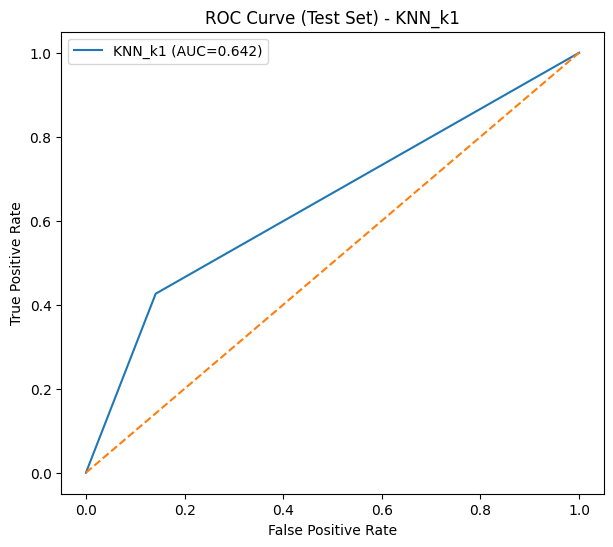

In [ ]:
# 4) ROC Curve (Test set) for KNN_k1

if result["y_score"] is not None:
    fpr, tpr, _ = roc_curve(y_test, result["y_score"])
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(7,6))
    plt.plot(fpr, tpr, label=f"KNN_k1 (AUC={roc_auc:.3f})")
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Test Set) - KNN_k1")
    plt.legend()
    plt.show()


= KNN_k3 =
Validation Accuracy: 0.8120
Test Accuracy:       0.8060
Precision:           0.5330
Recall:              0.3705
F1-score:            0.4371


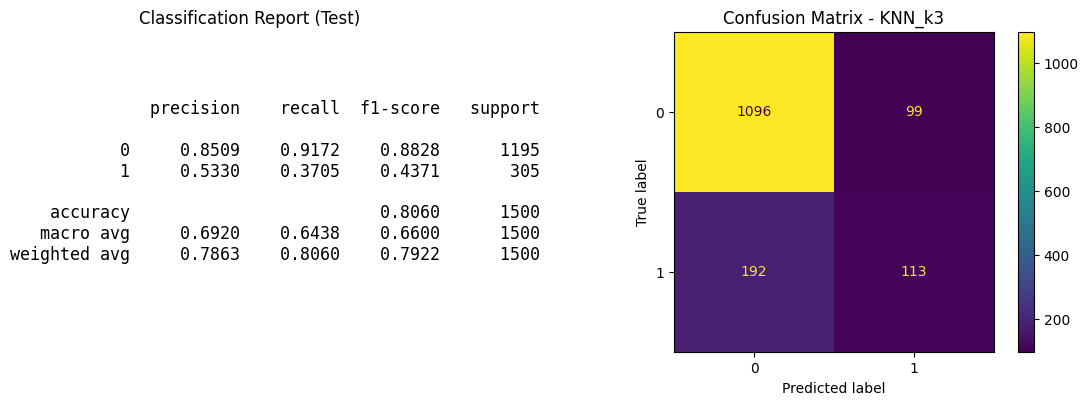

In [ ]:
model = KNeighborsClassifier(n_neighbors=3)

def evaluate_model(name, model, X_tr, y_tr, X_v, y_v, X_te, y_te):
    # Train
    model.fit(X_tr, y_tr)

    val_pred = model.predict(X_v)
    val_acc = accuracy_score(y_v, val_pred)

    y_pred = model.predict(X_te)
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    print(f"\n= {name} =")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Test Accuracy:       {acc:.4f}")
    print(f"Precision:           {prec:.4f}")
    print(f"Recall:              {rec:.4f}")
    print(f"F1-score:            {f1:.4f}")

    report = classification_report(y_te, y_pred, digits=4)
    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    fig = plt.figure(figsize=(12, 4))
    ax1 = fig.add_axes([0.05, 0.1, 0.4, 0.8])
    ax1.axis('off')
    ax1.text(0, 0.5, report, fontsize=12, va='center', family='monospace')
    ax1.set_title("Classification Report (Test)")
    ax2 = fig.add_axes([0.55, 0.1, 0.4, 0.8])
    disp.plot(ax=ax2, values_format='d', colorbar=True)
    ax2.set_title(f"Confusion Matrix - {name}")
    plt.show()

    # Probabilities for ROC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_te)
    else:
        y_score = None
    return {
        "Model": name,
        "Val_Acc": val_acc,
        "Test_Acc": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "y_score": y_score
    }

result = evaluate_model("KNN_k3", model, X_train, y_train, X_val, y_val, X_test, y_test)



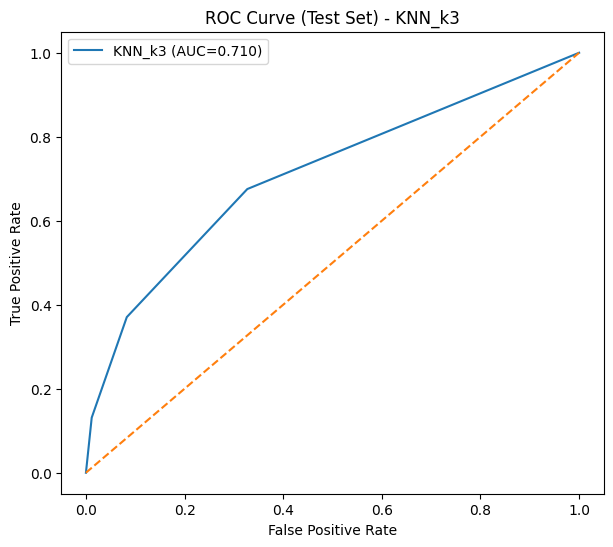

In [ ]:
# 4) ROC Curve (Test set) for KNN_k3

if result["y_score"] is not None:
    fpr, tpr, _ = roc_curve(y_test, result["y_score"])
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(7,6))
    plt.plot(fpr, tpr, label=f"KNN_k3 (AUC={roc_auc:.3f})")
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Test Set) - KNN_k3")
    plt.legend()
    plt.show()


= KNN_k5 =
Validation Accuracy: 0.8193
Test Accuracy:       0.8107
Precision:           0.5677
Recall:              0.2885
F1-score:            0.3826


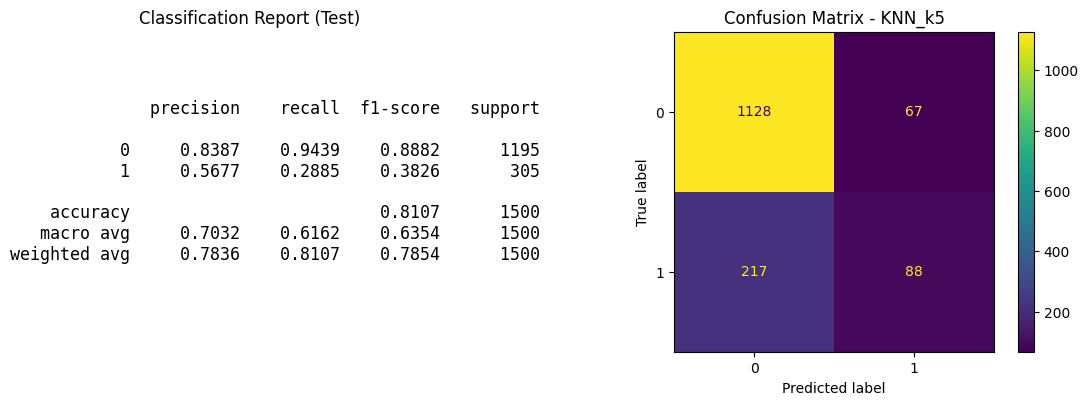

In [ ]:
model = KNeighborsClassifier(n_neighbors=5)

def evaluate_model(name, model, X_tr, y_tr, X_v, y_v, X_te, y_te):
    # Train
    model.fit(X_tr, y_tr)

    val_pred = model.predict(X_v)
    val_acc = accuracy_score(y_v, val_pred)

    y_pred = model.predict(X_te)
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    print(f"\n= {name} =")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Test Accuracy:       {acc:.4f}")
    print(f"Precision:           {prec:.4f}")
    print(f"Recall:              {rec:.4f}")
    print(f"F1-score:            {f1:.4f}")

    report = classification_report(y_te, y_pred, digits=4)
    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    fig = plt.figure(figsize=(12, 4))
    ax1 = fig.add_axes([0.05, 0.1, 0.4, 0.8])
    ax1.axis('off')
    ax1.text(0, 0.5, report, fontsize=12, va='center', family='monospace')
    ax1.set_title("Classification Report (Test)")
    ax2 = fig.add_axes([0.55, 0.1, 0.4, 0.8])
    disp.plot(ax=ax2, values_format='d', colorbar=True)
    ax2.set_title(f"Confusion Matrix - {name}")
    plt.show()

    # Probabilities for ROC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_te)
    else:
        y_score = None
    return {
        "Model": name,
        "Val_Acc": val_acc,
        "Test_Acc": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "y_score": y_score
    }

result = evaluate_model("KNN_k5", model, X_train, y_train, X_val, y_val, X_test, y_test)



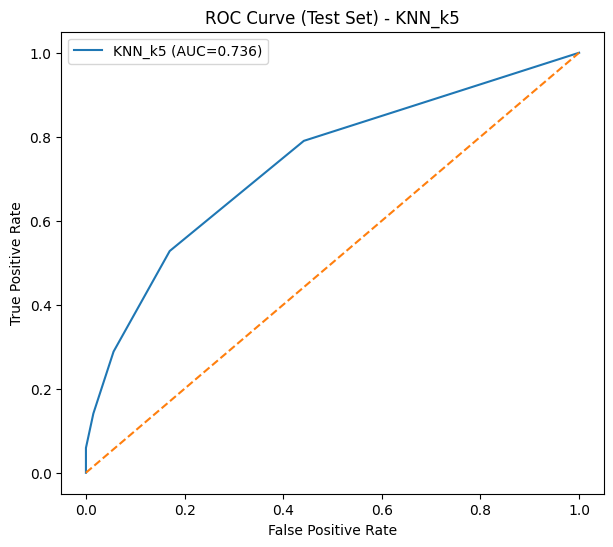

In [ ]:
# 4) ROC Curve (Test set) for KNN_k5

if result["y_score"] is not None:
    fpr, tpr, _ = roc_curve(y_test, result["y_score"])
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(7,6))
    plt.plot(fpr, tpr, label=f"KNN_k5 (AUC={roc_auc:.3f})")
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Test Set) - KNN_k5")
    plt.legend()
    plt.show()

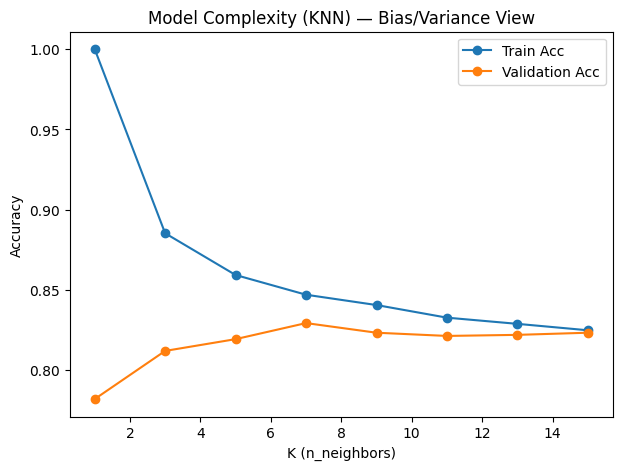

In [ ]:
k_values = [1,3,5,7,9,11,13,15]
knn_train_acc, knn_val_acc = [], []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    knn_train_acc.append(knn.score(X_train, y_train))
    knn_val_acc.append(knn.score(X_val, y_val))

plt.figure(figsize=(7,5))
plt.plot(k_values, knn_train_acc, marker='o', label='Train Acc')
plt.plot(k_values, knn_val_acc, marker='o', label='Validation Acc')
plt.xlabel("K (n_neighbors)")
plt.ylabel("Accuracy")
plt.title("Model Complexity (KNN) — Bias/Variance View")
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

X_train = pd.DataFrame(X_train)
y_train = pd.Series(y_train)
X_test = pd.DataFrame(X_test)
y_test = pd.Series(y_test)

model = KNeighborsClassifier(n_neighbors=1)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

val_accs, test_accs = [], []
val_precs, test_precs = [], []
val_recs, test_recs = [], []
val_f1s, test_f1s = [], []

for train_idx, val_idx in kfold.split(X_train, y_train):
    X_tr, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model.fit(X_tr, y_tr)

    # Validation metrics
    y_val_pred = model.predict(X_val_fold)
    val_accs.append(accuracy_score(y_val_fold, y_val_pred))
    val_precs.append(precision_score(y_val_fold, y_val_pred, zero_division=0))
    val_recs.append(recall_score(y_val_fold, y_val_pred, zero_division=0))
    val_f1s.append(f1_score(y_val_fold, y_val_pred, zero_division=0))

    # Test metrics (on original test set)
    y_test_pred = model.predict(X_test)
    test_accs.append(accuracy_score(y_test, y_test_pred))
    test_precs.append(precision_score(y_test, y_test_pred, zero_division=0))
    test_recs.append(recall_score(y_test, y_test_pred, zero_division=0))
    test_f1s.append(f1_score(y_test, y_test_pred, zero_division=0))

# Summary print
summary_dict = {
    "Validation Accuracy": np.mean(val_accs),
    "Validation Precision": np.mean(val_precs),
    "Validation Recall": np.mean(val_recs),
    "Validation F1Score": np.mean(val_f1s),
    "Test Accuracy": np.mean(test_accs),
    "Test Precision": np.mean(test_precs),
    "Test Recall": np.mean(test_recs),
    "Test F1Score": np.mean(test_f1s)
}

print("K-Fold Cross Validation Results (Mean Scores):")
for metric, score in summary_dict.items():
    print(f"{metric}: {score:.4f}")


K-Fold Cross Validation Results (Mean Scores):
Validation Accuracy: 0.7803
Validation Precision: 0.4557
Validation Recall: 0.4018
Validation F1Score: 0.4270
Test Accuracy: 0.7704
Test Precision: 0.4332
Test Recall: 0.4177
Test F1Score: 0.4252


In [ ]:
model = KNeighborsClassifier(n_neighbors=3)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

val_accs, test_accs = [], []
val_precs, test_precs = [], []
val_recs, test_recs = [], []
val_f1s, test_f1s = [], []

for train_idx, val_idx in kfold.split(X_train, y_train):
    X_tr, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model.fit(X_tr, y_tr)

    # Validation metrics
    y_val_pred = model.predict(X_val_fold)
    val_accs.append(accuracy_score(y_val_fold, y_val_pred))
    val_precs.append(precision_score(y_val_fold, y_val_pred, zero_division=0))
    val_recs.append(recall_score(y_val_fold, y_val_pred, zero_division=0))
    val_f1s.append(f1_score(y_val_fold, y_val_pred, zero_division=0))

    # Test metrics remain on original test set
    y_test_pred = model.predict(X_test)
    test_accs.append(accuracy_score(y_test, y_test_pred))
    test_precs.append(precision_score(y_test, y_test_pred, zero_division=0))
    test_recs.append(recall_score(y_test, y_test_pred, zero_division=0))
    test_f1s.append(f1_score(y_test, y_test_pred, zero_division=0))

# Summary print
summary_dict = {
    "Validation Accuracy": np.mean(val_accs),
    "Validation Precision": np.mean(val_precs),
    "Validation Recall": np.mean(val_recs),
    "Validation F1Score": np.mean(val_f1s),
    "Test Accuracy": np.mean(test_accs),
    "Test Precision": np.mean(test_precs),
    "Test Recall": np.mean(test_recs),
    "Test F1Score": np.mean(test_f1s)
}

print("K-Fold Cross Validation Results (Mean Scores):")
for metric, score in summary_dict.items():
    print(f"{metric}: {score:.4f}")


K-Fold Cross Validation Results (Mean Scores):
Validation Accuracy: 0.7993
Validation Precision: 0.5128
Validation Recall: 0.3079
Validation F1Score: 0.3846
Test Accuracy: 0.8043
Test Precision: 0.5295
Test Recall: 0.3416
Test F1Score: 0.4151


In [ ]:
model = KNeighborsClassifier(n_neighbors=5)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

val_accs, test_accs = [], []
val_precs, test_precs = [], []
val_recs, test_recs = [], []
val_f1s, test_f1s = [], []

for train_idx, val_idx in kfold.split(X_train, y_train):
    X_tr, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model.fit(X_tr, y_tr)

    # Validation metrics
    y_val_pred = model.predict(X_val_fold)
    val_accs.append(accuracy_score(y_val_fold, y_val_pred))
    val_precs.append(precision_score(y_val_fold, y_val_pred, zero_division=0))
    val_recs.append(recall_score(y_val_fold, y_val_pred, zero_division=0))
    val_f1s.append(f1_score(y_val_fold, y_val_pred, zero_division=0))

    # Test metrics remain on original test set
    y_test_pred = model.predict(X_test)
    test_accs.append(accuracy_score(y_test, y_test_pred))
    test_precs.append(precision_score(y_test, y_test_pred, zero_division=0))
    test_recs.append(recall_score(y_test, y_test_pred, zero_division=0))
    test_f1s.append(f1_score(y_test, y_test_pred, zero_division=0))

# Summary print
summary_dict = {
    "Validation Accuracy": np.mean(val_accs),
    "Validation Precision": np.mean(val_precs),
    "Validation Recall": np.mean(val_recs),
    "Validation F1Score": np.mean(val_f1s),
    "Test Accuracy": np.mean(test_accs),
    "Test Precision": np.mean(test_precs),
    "Test Recall": np.mean(test_recs),
    "Test F1Score": np.mean(test_f1s)
}

print("K-Fold Cross Validation Results of KNN_k5 (Mean Scores):")
for metric, score in summary_dict.items():
    print(f"{metric}: {score:.4f}")


K-Fold Cross Validation Results of KNN_k5 (Mean Scores):
Validation Accuracy: 0.8050
Validation Precision: 0.5456
Validation Recall: 0.2616
Validation F1Score: 0.3536
Test Accuracy: 0.8067
Test Precision: 0.5491
Test Recall: 0.2741
Test F1Score: 0.3656



= DecisionTree_Gini =
Validation Accuracy: 0.7967
Test Accuracy:       0.7967
Precision:           0.5000
Recall:              0.5180
F1-score:            0.5089


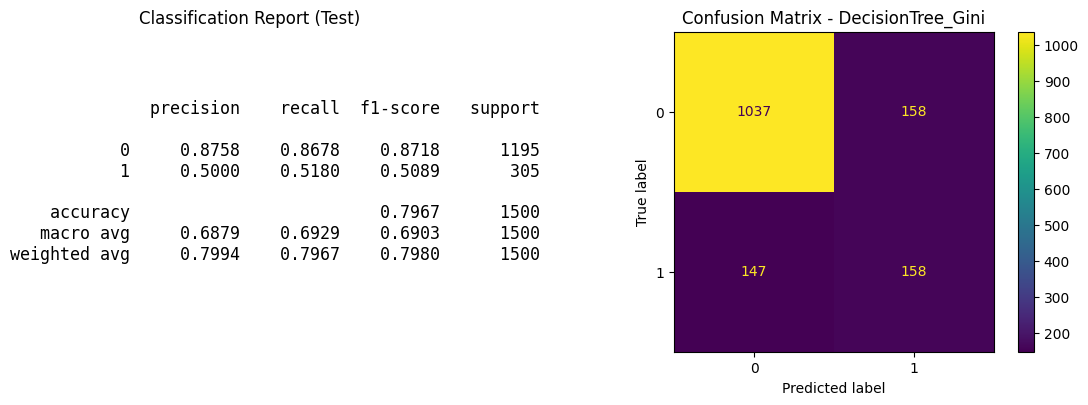

In [ ]:
# Decision Tree model
model_dt = DecisionTreeClassifier(criterion='gini', random_state=42)

# Evaluate Decision Tree model using the same evaluation function
result_dt = evaluate_model("DecisionTree_Gini", model_dt, X_train, y_train, X_val, y_val, X_test, y_test)



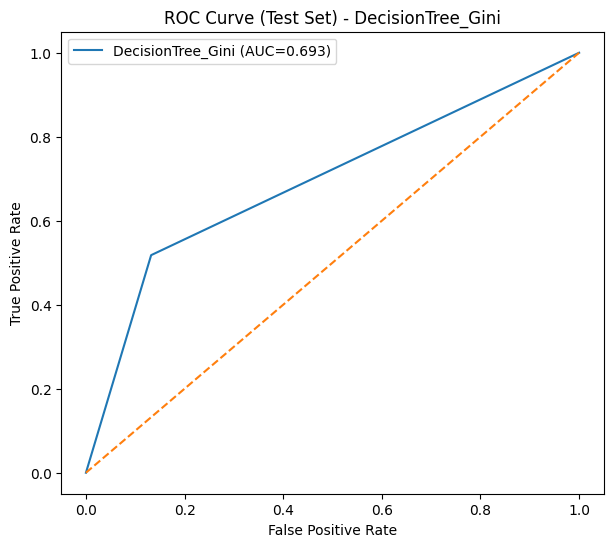

In [ ]:
# ROC Curve (Test set) for DecisionTree_Gini

if result_dt["y_score"] is not None:
    fpr, tpr, _ = roc_curve(y_test, result_dt["y_score"])
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(7,6))
    plt.plot(fpr, tpr, label=f"DecisionTree_Gini (AUC={roc_auc:.3f})")
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Test Set) - DecisionTree_Gini")
    plt.legend()
    plt.show()


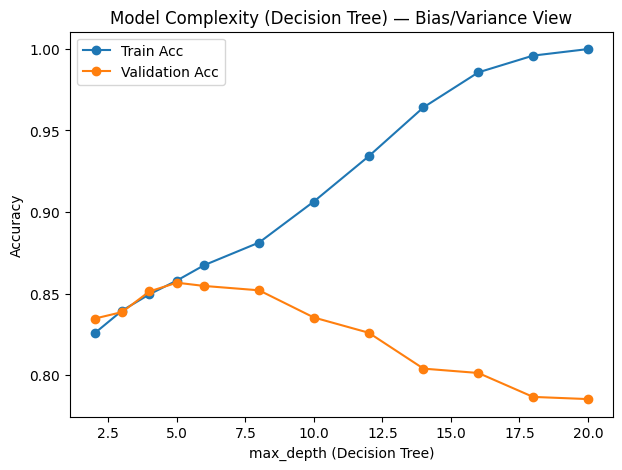

In [ ]:
#Decision Tree complexity
depth_values = [2,3,4,5,6,8,10,12,14,16,18,20]
dt_train_acc, dt_val_acc = [], []

for d in depth_values:
    dtc = DecisionTreeClassifier(criterion='gini', max_depth=d, random_state=42)
    dtc.fit(X_train, y_train)
    dt_train_acc.append(dtc.score(X_train, y_train))
    dt_val_acc.append(dtc.score(X_val, y_val))

plt.figure(figsize=(7,5))
plt.plot(depth_values, dt_train_acc, marker='o', label='Train Acc')
plt.plot(depth_values, dt_val_acc, marker='o', label='Validation Acc')
plt.xlabel("max_depth (Decision Tree)")
plt.ylabel("Accuracy")
plt.title("Model Complexity (Decision Tree) — Bias/Variance View")
plt.legend()
plt.show()

In [ ]:
model_dt = DecisionTreeClassifier(criterion='gini', random_state=42)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

val_accs_dt, test_accs_dt = [], []
val_precs_dt, test_precs_dt = [], []
val_recs_dt, test_recs_dt = [], []
val_f1s_dt, test_f1s_dt = [], []

for train_idx, val_idx in kfold.split(X_train, y_train):
    X_tr, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model_dt.fit(X_tr, y_tr)

    # Validation metrics
    y_val_pred = model_dt.predict(X_val_fold)
    val_accs_dt.append(accuracy_score(y_val_fold, y_val_pred))
    val_precs_dt.append(precision_score(y_val_fold, y_val_pred, zero_division=0))
    val_recs_dt.append(recall_score(y_val_fold, y_val_pred, zero_division=0))
    val_f1s_dt.append(f1_score(y_val_fold, y_val_pred, zero_division=0))

    # Test metrics on original test set
    y_test_pred = model_dt.predict(X_test)
    test_accs_dt.append(accuracy_score(y_test, y_test_pred))
    test_precs_dt.append(precision_score(y_test, y_test_pred, zero_division=0))
    test_recs_dt.append(recall_score(y_test, y_test_pred, zero_division=0))
    test_f1s_dt.append(f1_score(y_test, y_test_pred, zero_division=0))

# Summary print for DecisionTree
summary_dict_dt = {
    "Validation Accuracy": np.mean(val_accs_dt),
    "Validation Precision": np.mean(val_precs_dt),
    "Validation Recall": np.mean(val_recs_dt),
    "Validation F1Score": np.mean(val_f1s_dt),
    "Test Accuracy": np.mean(test_accs_dt),
    "Test Precision": np.mean(test_precs_dt),
    "Test Recall": np.mean(test_recs_dt),
    "Test F1Score": np.mean(test_f1s_dt),
}

print("DecisionTree K-Fold Cross Validation Results (Mean Scores):")
for metric, score in summary_dict_dt.items():
    print(f"{metric}: {score:.4f}")


DecisionTree K-Fold Cross Validation Results (Mean Scores):
Validation Accuracy: 0.7764
Validation Precision: 0.4557
Validation Recall: 0.4838
Validation F1Score: 0.4689
Test Accuracy: 0.7839
Test Precision: 0.4720
Test Recall: 0.5154
Test F1Score: 0.4923



= RandomForest =
Validation Accuracy: 0.8660
Test Accuracy:       0.8680
Precision:           0.7801
Recall:              0.4885
F1-score:            0.6008


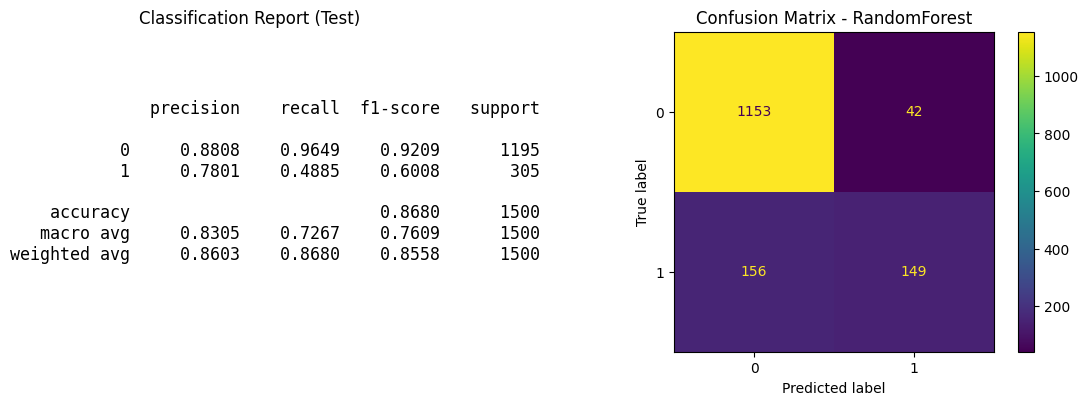

In [ ]:
#Random Forest model
model_rf = RandomForestClassifier(n_estimators=200, random_state=42)

# Evaluate Random Forest model using the same evaluation function
result_rf = evaluate_model("RandomForest", model_rf, X_train, y_train, X_val, y_val, X_test, y_test)



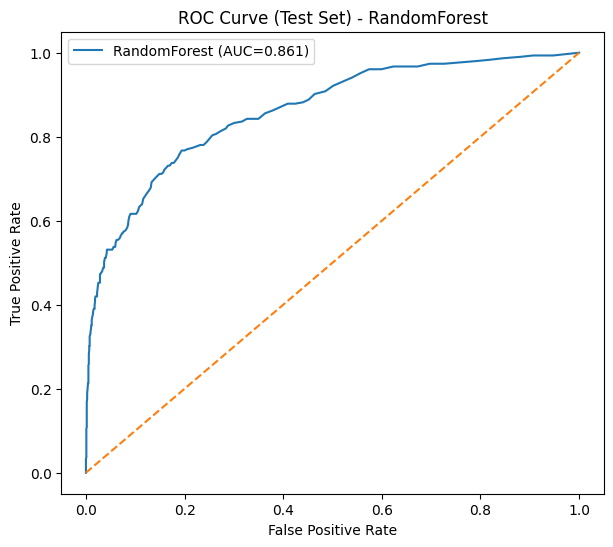

In [ ]:
# ROC Curve (Test set) for RandomForest

if result_rf["y_score"] is not None:
    fpr, tpr, _ = roc_curve(y_test, result_rf["y_score"])
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(7,6))
    plt.plot(fpr, tpr, label=f"RandomForest (AUC={roc_auc:.3f})")
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Test Set) - RandomForest")
    plt.legend()
    plt.show()


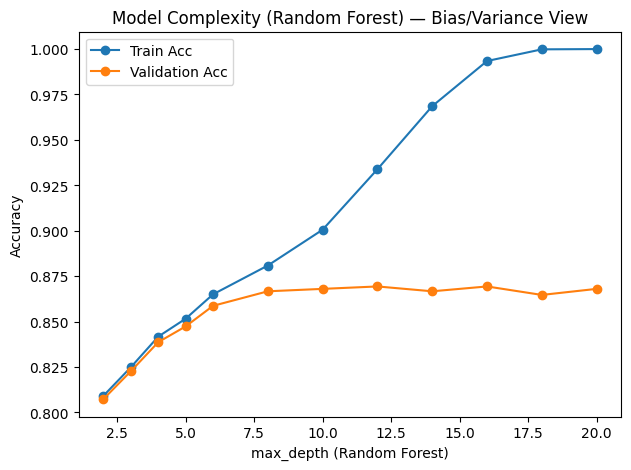

In [ ]:
# Random Forest complexity
depth_values = [2, 3, 4, 5, 6, 8, 10, 12, 14, 16, 18, 20]
rf_train_acc, rf_val_acc = [], []

for d in depth_values:
    rfc = RandomForestClassifier(n_estimators=200, max_depth=d, random_state=42)
    rfc.fit(X_train, y_train)
    rf_train_acc.append(rfc.score(X_train, y_train))
    rf_val_acc.append(rfc.score(X_val, y_val))

plt.figure(figsize=(7,5))
plt.plot(depth_values, rf_train_acc, marker='o', label='Train Acc')
plt.plot(depth_values, rf_val_acc, marker='o', label='Validation Acc')
plt.xlabel("max_depth (Random Forest)")
plt.ylabel("Accuracy")
plt.title("Model Complexity (Random Forest) — Bias/Variance View")
plt.legend()
plt.show()


In [ ]:
model_rf = RandomForestClassifier(n_estimators=200, random_state=42)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

val_accs_rf, test_accs_rf = [], []
val_precs_rf, test_precs_rf = [], []
val_recs_rf, test_recs_rf = [], []
val_f1s_rf, test_f1s_rf = [], []

for train_idx, val_idx in kfold.split(X_train, y_train):
    X_tr, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model_rf.fit(X_tr, y_tr)

    # Validation metrics
    y_val_pred = model_rf.predict(X_val_fold)
    val_accs_rf.append(accuracy_score(y_val_fold, y_val_pred))
    val_precs_rf.append(precision_score(y_val_fold, y_val_pred, zero_division=0))
    val_recs_rf.append(recall_score(y_val_fold, y_val_pred, zero_division=0))
    val_f1s_rf.append(f1_score(y_val_fold, y_val_pred, zero_division=0))

    # Test metrics on original test set
    y_test_pred = model_rf.predict(X_test)
    test_accs_rf.append(accuracy_score(y_test, y_test_pred))
    test_precs_rf.append(precision_score(y_test, y_test_pred, zero_division=0))
    test_recs_rf.append(recall_score(y_test, y_test_pred, zero_division=0))
    test_f1s_rf.append(f1_score(y_test, y_test_pred, zero_division=0))

# Summary print for RandomForest
summary_dict_rf = {
    "Validation Accuracy": np.mean(val_accs_rf),
    "Validation Precision": np.mean(val_precs_rf),
    "Validation Recall": np.mean(val_recs_rf),
    "Validation F1Score": np.mean(val_f1s_rf),
    "Test Accuracy": np.mean(test_accs_rf),
    "Test Precision": np.mean(test_precs_rf),
    "Test Recall": np.mean(test_recs_rf),
    "Test F1Score": np.mean(test_f1s_rf),
}

print("RandomForest K-Fold Cross Validation Results (Mean Scores):")
for metric, score in summary_dict_rf.items():
    print(f"{metric}: {score:.4f}")


RandomForest K-Fold Cross Validation Results (Mean Scores):
Validation Accuracy: 0.8570
Validation Precision: 0.7598
Validation Recall: 0.4355
Validation F1Score: 0.5534
Test Accuracy: 0.8641
Test Precision: 0.7723
Test Recall: 0.4708
Test F1Score: 0.5848



= AdaBoost =
Validation Accuracy: 0.8593
Test Accuracy:       0.8627
Precision:           0.7619
Recall:              0.4721
F1-score:            0.5830


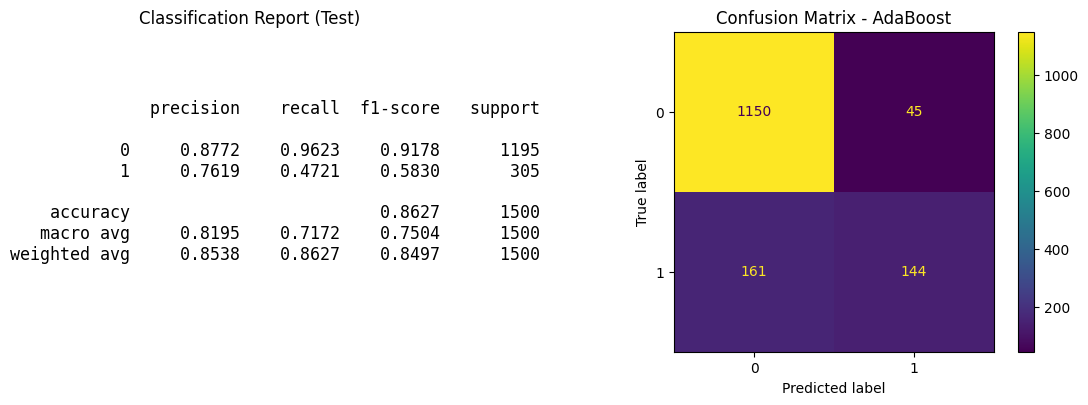

In [ ]:
# AdaBoost model
model_ada = AdaBoostClassifier(n_estimators=200, random_state=42)

# Evaluate AdaBoost model using the same evaluation function
result_ada = evaluate_model("AdaBoost", model_ada, X_train, y_train, X_val, y_val, X_test, y_test)


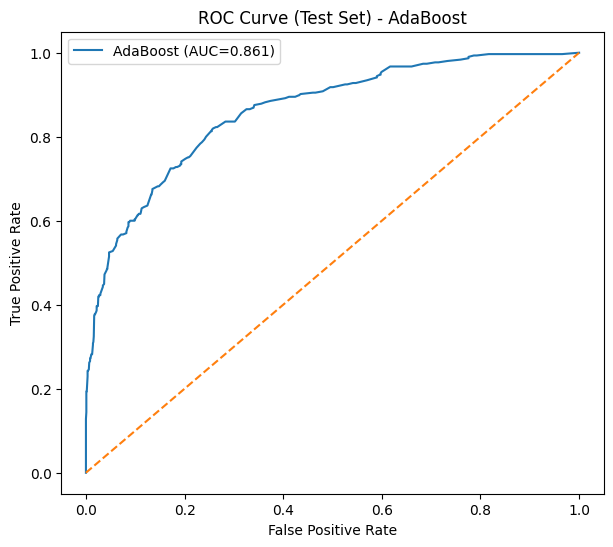

In [ ]:
# ROC Curve (Test set) for AdaBoost

if result_ada["y_score"] is not None:
    fpr, tpr, _ = roc_curve(y_test, result_ada["y_score"])
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(7,6))
    plt.plot(fpr, tpr, label=f"AdaBoost (AUC={roc_auc:.3f})")
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Test Set) - AdaBoost")
    plt.legend()
    plt.show()


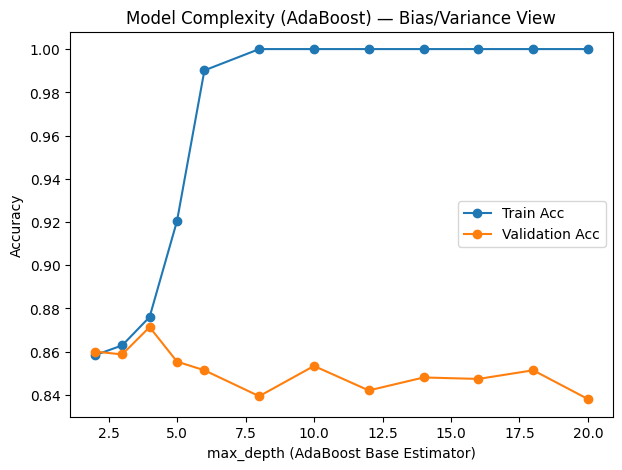

In [ ]:
depth_values = [2, 3, 4, 5, 6, 8, 10, 12, 14, 16, 18, 20]
ada_train_acc = []
ada_val_acc = []

for d in depth_values:
    base_estimator = DecisionTreeClassifier(max_depth=d, random_state=42)
    ada = AdaBoostClassifier(estimator=base_estimator, n_estimators=200, random_state=42)
    ada.fit(X_train, y_train)
    ada_train_acc.append(ada.score(X_train, y_train))
    ada_val_acc.append(ada.score(X_val, y_val))

plt.figure(figsize=(7,5))
plt.plot(depth_values, ada_train_acc, marker='o', label='Train Acc')
plt.plot(depth_values, ada_val_acc, marker='o', label='Validation Acc')
plt.xlabel("max_depth (AdaBoost Base Estimator)")
plt.ylabel("Accuracy")
plt.title("Model Complexity (AdaBoost) — Bias/Variance View")
plt.legend()
plt.show()


In [ ]:
model_ada = AdaBoostClassifier(n_estimators=200, random_state=42)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

val_accs_ada, test_accs_ada = [], []
val_precs_ada, test_precs_ada = [], []
val_recs_ada, test_recs_ada = [], []
val_f1s_ada, test_f1s_ada = [], []

for train_idx, val_idx in kfold.split(X_train, y_train):
    X_tr, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model_ada.fit(X_tr, y_tr)

    # Validation metrics
    y_val_pred = model_ada.predict(X_val_fold)
    val_accs_ada.append(accuracy_score(y_val_fold, y_val_pred))
    val_precs_ada.append(precision_score(y_val_fold, y_val_pred, zero_division=0))
    val_recs_ada.append(recall_score(y_val_fold, y_val_pred, zero_division=0))
    val_f1s_ada.append(f1_score(y_val_fold, y_val_pred, zero_division=0))

    # Test metrics on original test set
    y_test_pred = model_ada.predict(X_test)
    test_accs_ada.append(accuracy_score(y_test, y_test_pred))
    test_precs_ada.append(precision_score(y_test, y_test_pred, zero_division=0))
    test_recs_ada.append(recall_score(y_test, y_test_pred, zero_division=0))
    test_f1s_ada.append(f1_score(y_test, y_test_pred, zero_division=0))

# Summary print for AdaBoost
summary_dict_ada = {
    "Validation Accuracy": np.mean(val_accs_ada),
    "Validation Precision": np.mean(val_precs_ada),
    "Validation Recall": np.mean(val_recs_ada),
    "Validation F1Score": np.mean(val_f1s_ada),
    "Test Accuracy": np.mean(test_accs_ada),
    "Test Precision": np.mean(test_precs_ada),
    "Test Recall": np.mean(test_recs_ada),
    "Test F1Score": np.mean(test_f1s_ada),
}

print("AdaBoost K-Fold Cross Validation Results (Mean Scores):")
for metric, score in summary_dict_ada.items():
    print(f"{metric}: {score:.4f}")


AdaBoost K-Fold Cross Validation Results (Mean Scores):
Validation Accuracy: 0.8500
Validation Precision: 0.7251
Validation Recall: 0.4250
Validation F1Score: 0.5353
Test Accuracy: 0.8644
Test Precision: 0.7780
Test Recall: 0.4675
Test F1Score: 0.5836



= GradientBoosting =
Validation Accuracy: 0.8687
Test Accuracy:       0.8747
Precision:           0.7940
Recall:              0.5180
F1-score:            0.6270


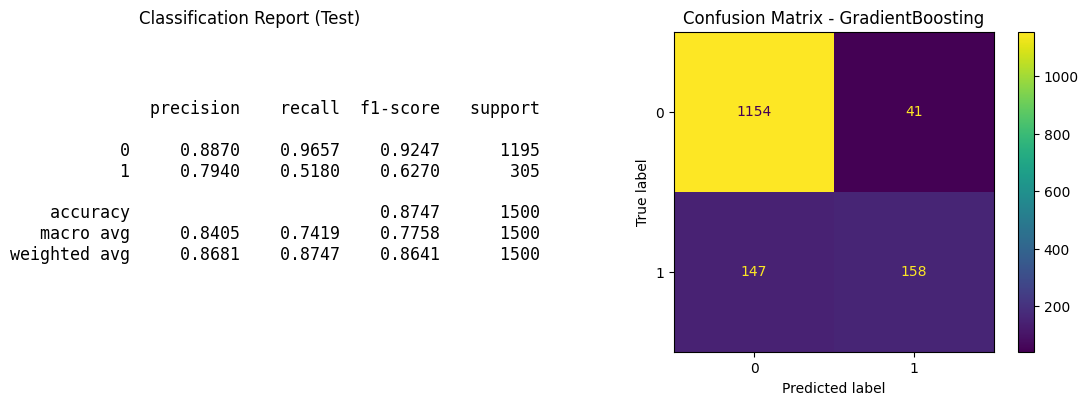

In [ ]:
# Gradient Boosting model
model_gb = GradientBoostingClassifier(n_estimators=200, random_state=42)

# Evaluate Gradient Boosting model using the same evaluation function
result_gb = evaluate_model("GradientBoosting", model_gb, X_train, y_train, X_val, y_val, X_test, y_test)


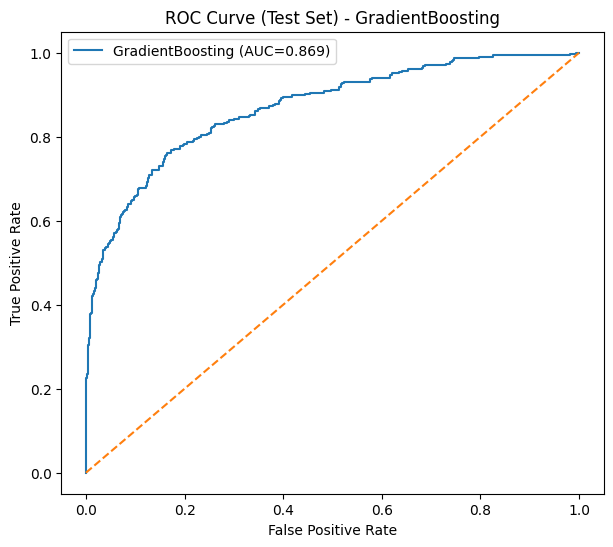

In [ ]:
# ROC Curve (Test set) for GradientBoosting

if result_gb["y_score"] is not None:
    fpr, tpr, _ = roc_curve(y_test, result_gb["y_score"])
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(7,6))
    plt.plot(fpr, tpr, label=f"GradientBoosting (AUC={roc_auc:.3f})")
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Test Set) - GradientBoosting")
    plt.legend()
    plt.show()


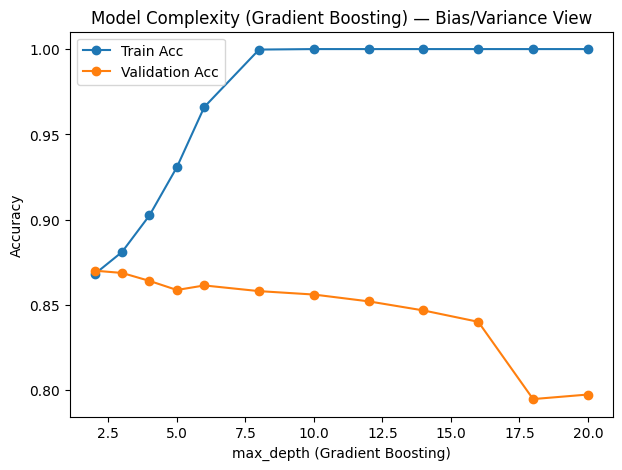

In [ ]:
depth_values = [2, 3, 4, 5, 6, 8, 10, 12, 14, 16, 18, 20]
gb_train_acc = []
gb_val_acc = []

for d in depth_values:
    gb = GradientBoostingClassifier(max_depth=d, n_estimators=200, random_state=42)
    gb.fit(X_train, y_train)
    gb_train_acc.append(gb.score(X_train, y_train))
    gb_val_acc.append(gb.score(X_val, y_val))

plt.figure(figsize=(7,5))
plt.plot(depth_values, gb_train_acc, marker='o', label='Train Acc')
plt.plot(depth_values, gb_val_acc, marker='o', label='Validation Acc')
plt.xlabel("max_depth (Gradient Boosting)")
plt.ylabel("Accuracy")
plt.title("Model Complexity (Gradient Boosting) — Bias/Variance View")
plt.legend()
plt.show()


In [ ]:
model_gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

val_accs_gb, test_accs_gb = [], []
val_precs_gb, test_precs_gb = [], []
val_recs_gb, test_recs_gb = [], []
val_f1s_gb, test_f1s_gb = [], []

for train_idx, val_idx in kfold.split(X_train, y_train):
    X_tr, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model_gb.fit(X_tr, y_tr)

    # Validation metrics
    y_val_pred = model_gb.predict(X_val_fold)
    val_accs_gb.append(accuracy_score(y_val_fold, y_val_pred))
    val_precs_gb.append(precision_score(y_val_fold, y_val_pred, zero_division=0))
    val_recs_gb.append(recall_score(y_val_fold, y_val_pred, zero_division=0))
    val_f1s_gb.append(f1_score(y_val_fold, y_val_pred, zero_division=0))

    # Test metrics on original test set
    y_test_pred = model_gb.predict(X_test)
    test_accs_gb.append(accuracy_score(y_test, y_test_pred))
    test_precs_gb.append(precision_score(y_test, y_test_pred, zero_division=0))
    test_recs_gb.append(recall_score(y_test, y_test_pred, zero_division=0))
    test_f1s_gb.append(f1_score(y_test, y_test_pred, zero_division=0))

# Summary print for GradientBoosting
summary_dict_gb = {
    "Validation Accuracy": np.mean(val_accs_gb),
    "Validation Precision": np.mean(val_precs_gb),
    "Validation Recall": np.mean(val_recs_gb),
    "Validation F1Score": np.mean(val_f1s_gb),
    "Test Accuracy": np.mean(test_accs_gb),
    "Test Precision": np.mean(test_precs_gb),
    "Test Recall": np.mean(test_recs_gb),
    "Test F1Score": np.mean(test_f1s_gb),
}

print("GradientBoosting K-Fold Cross Validation Results (Mean Scores):")
for metric, score in summary_dict_gb.items():
    print(f"{metric}: {score:.4f}")


GradientBoosting K-Fold Cross Validation Results (Mean Scores):
Validation Accuracy: 0.8617
Validation Precision: 0.7591
Validation Recall: 0.4705
Validation F1Score: 0.5806
Test Accuracy: 0.8689
Test Precision: 0.7740
Test Recall: 0.5023
Test F1Score: 0.6091
